### An Invitation to Analytic Combinatorics - Lecture 6

This SageMath notebook contains the Sage code presented in Lecture 6 of the MPI Lecture Series presented by Stephen Melczer in June 2026.

### Part 1: Non-Smooth ACSV

In [1]:
var('x y')
from sage_acsv import diagonal_asymptotics_hyperplane
H = (1-2*x/3-y/3)*(1-3*x/4-y/4)

# Case 1: 0 < r/(r+s) < 2/3
diagonal_asymptotics_hyperplane(1/H, r = [1,1])

16/sqrt(pi)*(8/9)^n*n^(-1/2) + O((8/9)^n*n^(-3/2))

In [2]:
# Case 2: 3/4 < r/(r+s)
diagonal_asymptotics_hyperplane(1/H, r = [4,1])

35.57562367689427?/sqrt(pi)*(253125/262144)^n*n^(-1/2) + O((253125/262144)^n*n^(-3/2))

In [3]:
# Case 3: 2/3 < r/(r+s) < 3/4
# Note exponentially small error
diagonal_asymptotics_hyperplane(1/H, r = [5,2])

12 + O((200120949/204800000)^n*n^(-1))

In [4]:
# Our general asymptotics function calls the hyperplane code when applicable
from sage_acsv import diagonal_asymptotics_combinatorial as diagonal
diagonal(1/H, r = [5,2])

12 + O((200120949/204800000)^n*n^(-1))

In [5]:
# Try non-generic direction
try:
    diagonal(1/H, r = [2,1])
except Exception as e:
    print(e)

Non-generic direction detected - critical point [1, 1] is contained in 0-dimensional stratum


In [6]:
# Decompose non-simple function into sum of simple functions
from sage_acsv.decomposition import compute_leinartas_decomposition as decomp
R.<x,y> = PolynomialRing(QQ, 2)
DE = decomp(R,1,(2-x-y)*(3-2*x-y)*(3-x-2*y))
show(add([SR(p[0])/SR(p[1]).factor() for p in DE]))

-1/3/((2*x + y - 3)*(x + y - 2)^2) - 1/3/((x + 2*y - 3)*(x + y - 2)^2)

In [7]:
show(add([SR(p[0])/SR(p[1]) for p in DE]).factor())

-1/((2*x + y - 3)*(x + 2*y - 3)*(x + y - 2))

In [8]:
# Compute Gelfand-Shilov cohomology decomposition
from sage_acsv.decomposition import compute_cohomology_decomposition
R = QQ[x,y]
var('x y n')
G, H = x^(-n-1)*y^(-n-1), R((2-x-y)^2*(3-2*x-y))
g, h = compute_cohomology_decomposition(R, G, H)
show(SR(g)/SR(h).factor())

(2*(n + 1)*x - (n + 1)*y)*x^(-n - 2)*y^(-n - 2)/((2*x + y - 3)*(x + y - 2))

In [9]:
# Verify cohomology decomposition by checking coefficient
A.<x, y> = LazyPowerSeriesRing(QQ)
F1 = 1/(2-x-y)^2/(3-2*x-y)
F2 = 1/(2-x-y)/(3-2*x-y)
N = 10
print(F1[2*N][N,N])
print(2*(N+1)*F2[2*N+1][N,N+1] - (N+1)*F2[2*N+1][N+1,N])

31496773017568375/10968475320188928
31496773017568375/10968475320188928


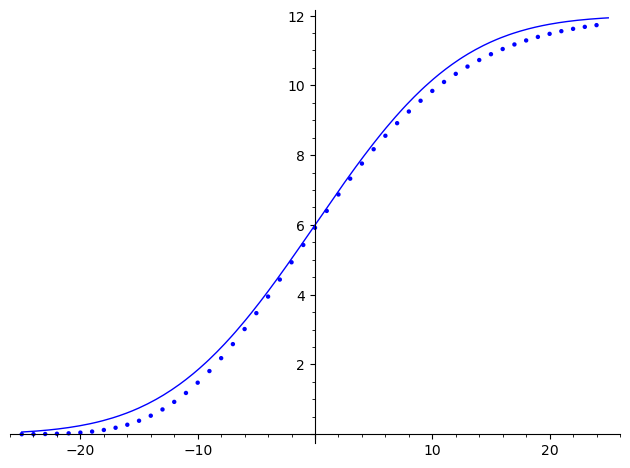

In [10]:
# Study asymptotic transition at square-root scale around non-generic direction
A.<x, y> = LazyPowerSeriesRing(QQ)
F = 1 / ((1 - 2*x/3 - y/3) * (1 - 3*x/4 - y/4))
N = 16

pts = []
for t in range(-25, 25):
    i = 2*N^2 + N*3/4*t
    j = N^2 + N/4*t
    H_k = F[i + j]
    pts += [[t,H_k[i, j]]]

var('t')
point(pts) + plot(6*erf(t/sqrt(192))+6,t,-25,25)

### Part 2: Non-Smooth ACSV

In [11]:
# Compute Whitney Stratification
from sage_acsv import whitney_stratification
R.<x, y, z> = PolynomialRing(QQ, 3)
IX = Ideal(y^2 + z^3 - x^2*z^2); IX

Ideal (-x^2*z^2 + z^3 + y^2) of Multivariate Polynomial Ring in x, y, z over Rational Field

In [12]:
whitney_stratification(IX, R)

[Ideal (z, y, x) of Multivariate Polynomial Ring in x, y, z over Rational Field,
 Ideal (z, y) of Multivariate Polynomial Ring in x, y, z over Rational Field,
 Ideal (x^2*z^2 - z^3 - y^2) of Multivariate Polynomial Ring in x, y, z over Rational Field]

In [13]:
# Show Whitney umbrella using parametric plot
var('u, t')
v_new = t * sqrt(u^2 + 1)
x_p = u
y_p = v_new * (u^2 - v_new^2)
z_p = u^2 - v_new^2

plot_param = parametric_plot3d(
    (x_p, y_p, z_p), 
    (u, -2, 2), 
    (t, -1, 1), 
    color='lightblue', 
    smooth=True,
    opacity=0.6,
    frame=False
)
singular_line = line3d(
    [(-3, 0, 0), (3, 0, 0)], 
    color='orange', 
    thickness=10
)
pinch_point = point3d(
    (0, 0, 0), 
    color='red', 
    size=100 
)

# Combine and display the plots with the dark theme for a black background
(plot_param + singular_line + pinch_point).show(viewer='threejs')

Graphics3d Object

In [14]:
# Computing critical points with a cone singularity
# This example takes very long without setting the gröbner basis backend to Macaulay2
# The backend is only set if M2 is installed (if you don't have it, be prepared to wait...)
from sage_acsv import ACSVSettings as AS, critical_points
from shutil import which
if which("M2"):
    AS.set_default_groebner_backend(AS.Groebner.MACAULAY2)
var('w x y z')
H = 1 - (w + x + y + z) + 27*w*x*y*z
critical_points(1/H)

[[1/3, 1/3, 1/3, 1/3],
 [-0.3333333333333334? - 0.4714045207910317?*I,
  -0.3333333333333334? - 0.4714045207910317?*I,
  -0.3333333333333334? - 0.4714045207910317?*I,
  -0.3333333333333334? - 0.4714045207910317?*I],
 [-0.3333333333333334? + 0.4714045207910317?*I,
  -0.3333333333333334? + 0.4714045207910317?*I,
  -0.3333333333333334? + 0.4714045207910317?*I,
  -0.3333333333333334? + 0.4714045207910317?*I]]

In [15]:
# We see the cone singularity
H2 = H.subs(x=x+1/3,y=y+1/3,z=z+1/3,w=w+1/3)
H2.taylor((w,0),(x,0),(y,0),(z,0),2).expand()

3*w*x + 3*w*y + 3*x*y + 3*w*z + 3*x*z + 3*y*z

In [16]:
# Check for minimal critical points
from sage_acsv import minimal_critical_points_combinatorial
minimal_critical_points_combinatorial(1/H)

[[1/3, 1/3, 1/3, 1/3]]

In [17]:
# Function whose diagonal counts N,SE,SW quadrant walks
from sage_acsv import minimal_critical_points_combinatorial as MC, contributing_points_combinatorial as CONTRIB
var('x,y,z')
G = (1 + x)*(2*z*x^2*y^2 + 2*z*y^2 - 1)
H = (-1 + y)*(z*x^2*y^2 + z*y^2 + z*x - 1)*(z*x^2*y^2 + z*y^2 - 1)

In [18]:
# There are 5 minimal critical points.
MC(G/H)

[[1, 1, 1/3],
 [1, 0.7071067811865475?, 1/2],
 [1, -0.7071067811865475?, 1/2],
 [-1, -0.7071067811865475?*I, -1/2],
 [-1, 0.7071067811865475?*I, -1/2]]

In [19]:
# There are only 4 contributing points.
CONTRIB(G/H)

[[1, -0.7071067811865475?, 1/2],
 [1, 0.7071067811865475?, 1/2],
 [-1, 0.7071067811865475?*I, -1/2],
 [-1, -0.7071067811865475?*I, -1/2]]

In [20]:
# Find diagonal asymptotics -- not enough precision!
from sage_acsv import diagonal_asymptotics_combinatorial as diagonal
diagonal(G/H)

O(2.828427124746190?^n*n^(-2))

In [21]:
diagonal(G/H, expansion_precision = 2)

0.9705627484771406?/pi*2.828427124746190?^n*n^(-2)*(e^(I*arg(-1)))^n + 32.97056274847714?/pi*2.828427124746190?^n*n^(-2) + O(2.828427124746190?^n*n^(-3))

### Part 3: A Geometric Framework

In [22]:
# Example computing \kappa_w
# This just speeds up the following critical point computation for the sage_acsv package using Macaulay2
# The code still works without it, it's just slower computing the non-smooth critical point (1/3,1/3,1/3,1/3)
# The backend is only set if M2 is installed on the user's system
from sage_acsv import ACSVSettings as AS
from shutil import which
if which("M2"):
    AS.set_default_groebner_backend(AS.Groebner.MACAULAY2)

In [23]:
# Get coefficients in rational diagonal asymptotics
from sage_acsv import compute_asymptotics_at_points as CAP
from sage_acsv import get_expansion_terms, critical_points
var('w,x,y,z')
F = 1/(1 - (w + x + y + z) + 27*w*x*y*z)
CPs = critical_points(F)[1:]
C1 = [term.coefficient * CBF(term.pi_factor) for term in get_expansion_terms(CAP(F, CPs))]
C1

[[0.1022028690346556 +/- 8.27e-17] + [0.0488112981861280 +/- 7.71e-17]*I,
 [0.1022028690346556 +/- 8.27e-17] + [-0.0488112981861280 +/- 7.71e-17]*I]

In [24]:
# Get coefficients in D-finite asymptotics
from ore_algebra.analytic.singularity_analysis import bound_coefficients as BC
from sage_periods import compute_diagonal_annihilator as diagonal
asm = BC(diagonal(F), [1, -3], order=1)
C2 = [term.coefficient for term in list(asm.series_factor().summands)[0:2]]
C2

[[0.306608607103967 +/- 5.52e-16] + [0.146433894558384 +/- 2.88e-16]*I,
 [0.306608607103967 +/- 5.52e-16] + [-0.146433894558384 +/- 2.88e-16]*I]

In [25]:
# This is an integer -- therefore we have solved the connection problem!
C2[0]/C1[0]

[3.00000000000000 +/- 7.88e-15] + [+/- 5.90e-15]*I

### Figures with Black Backgrounds for Slides

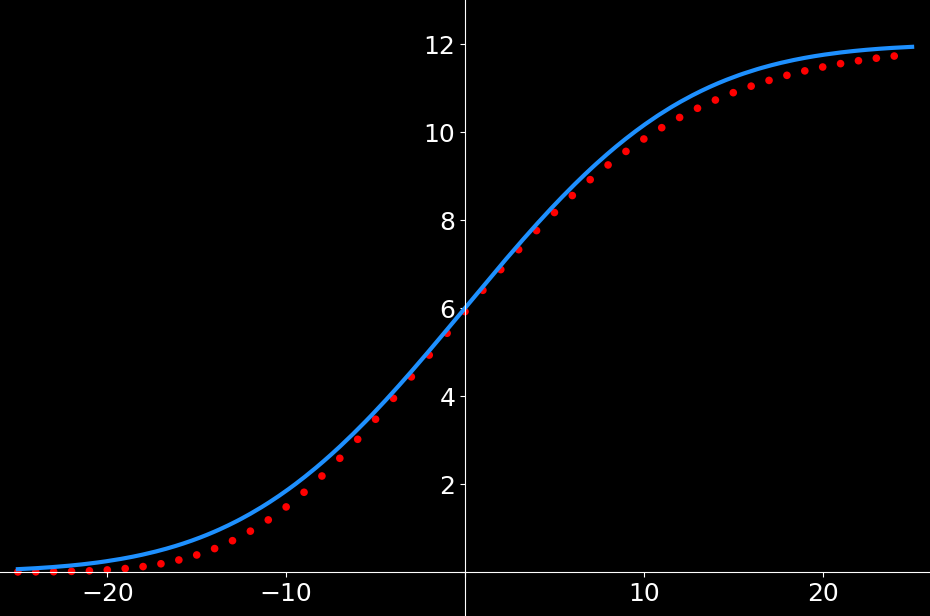

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.rcParams['savefig.pad_inches'] = 0
plt.rcParams['savefig.bbox'] = 'standard'
plt.style.use('dark_background')
plt.rc('font', size=14)

A.<x, y> = LazyPowerSeriesRing(QQ)
F = 1 / ((1 - 2*x/3 - y/3) * (1 - 3*x/4 - y/4))
N = 16

pts = []
for t in range(-25, 25):
    # Force integer types to prevent index errors
    i = ZZ(2*N^2 + N*3/4*t)
    j = ZZ(N^2 + N/4*t)
    
    H_k = F[i + j]
    pts.append([t, H_k[i, j]])

var('t_sym')
P = point(pts, size=30, color='red', axes=False, frame=False)
L = plot(6*erf(t_sym/sqrt(192)) + 6, (t_sym, -25, 25), color='dodgerblue', thickness=3, axes=False, frame=False)
combined_plot = P + L

fig = combined_plot.matplotlib(figsize=(12, 8))
fig.set_facecolor('black')
ax = fig.axes[0]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('white')
ax.yaxis.set_major_locator(MultipleLocator(2)) 
ax.tick_params(colors='white', direction='out', which='major', labelsize=18)
ax.minorticks_off()
ax.set_ylim(-1, 13)

fig